In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Read in the pickle
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [12]:
# List of bounding boxes for the ball 
ball_positions = [x.get(1, []) for x in ball_positions] # if there is a ball detection, store it, otherwise just append an empty list
# Convert the list into a pandas df
df_ball_positions = pd.DataFrame(ball_positions, columns=['x1', 'y1', 'x2', 'y2'])

# Interpolate the missing values (empty list in the ball positions list)
df_ball_positions = df_ball_positions.interpolate() # if something is missing between 2 frames then we interpolate
df_ball_positions = df_ball_positions.bfill()

In [13]:
# Calculate the middle of the ball
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

In [14]:
df_ball_positions.head()

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean
0,837.48938,670.454041,854.398071,689.370361,679.912201,679.912201
1,837.48938,670.454041,854.398071,689.370361,679.912201,679.912201
2,837.48938,670.454041,854.398071,689.370361,679.912201,679.912201
3,837.48938,670.454041,854.398071,689.370361,679.912201,679.912201
4,837.48938,670.454041,854.398071,689.370361,679.912201,679.912201


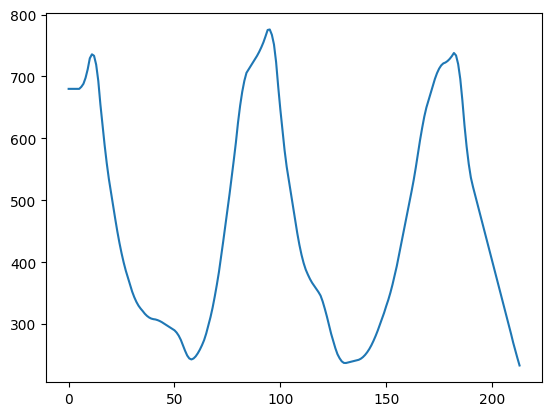

In [15]:
# Plot the mid_y_rolling mean
plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [17]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

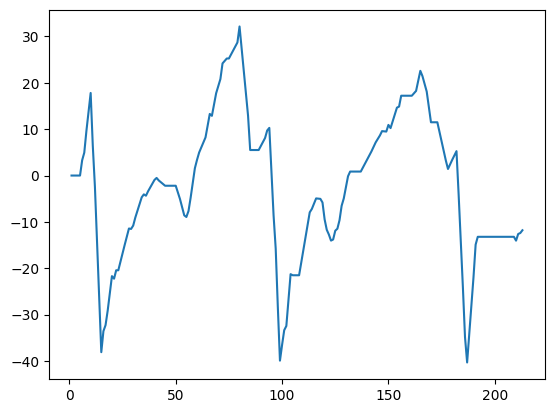

In [ ]:
# Plot to understand where the ball was hit
plt.plot(df_ball_positions['delta_y'])

In [19]:
df_ball_positions['ball_hit'] = 0 # initialise ball positions

In [ ]:
# List of bounding boxes for the ball 
ball_positions = [x.get(1, []) for x in ball_positions] # if there is a ball detection, store it, otherwise just append an empty list
# Convert the list into a pandas df
df_ball_positions = pd.DataFrame(ball_positions, columns=['x1', 'y1', 'x2', 'y2'])

# Calculate the middle of the ball
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()
df_ball_positions['ball_hit'] = 0 # initialise ball positions

minimum_change_frames_for_hit = 25
for i in range(1, len(df_ball_positions) - int(minimum_change_frames_for_hit*1.2)):
    negative_position_change = df_ball_positions.loc[i, 'delta_y'] > 0 and df_ball_positions.loc[i+1, 'delta_y'] < 0
    positive_position_change = df_ball_positions.loc[i, 'delta_y'] < 0 and df_ball_positions.loc[i+1, 'delta_y'] > 0

    if negative_position_change or positive_position_change:
        change_count = 0

        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2) + 1):
            negative_position_change_following_frame = df_ball_positions.loc[i, 'delta_y'] > 0 and df_ball_positions.loc[i+1, 'delta_y'] < 0
            positive_position_change_following_frame = df_ball_positions.loc[i, 'delta_y'] < 0 and df_ball_positions.loc[i+1, 'delta_y'] > 0

            if negative_position_change and negative_position_change_following_frame:
                change_count += 1
            elif positive_position_change and positive_position_change_following_frame:
                change_count += 1
        
        if change_count > minimum_change_frames_for_hit - 1:
            df_ball_positions.loc[i, 'ball_hit'] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()